# 03 — Arquitetura base: transformer decoder-only (estilo GPT-2)

> Escopo: a arquitetura base *decoder-only*, no padrão GPT-2. A intuição
> das peças (atenção, Q/K/V, máscara causal, MLP, resíduo) veio do notebook 01;
> aqui elas viram `nn.Module` e são **montadas num modelo que roda**.

Este notebook constrói a versão **base**, fiel ao GPT-2 (2019):
**LayerNorm**, **embedding posicional aprendida** e **MLP com GELU e expansão 4d**.
O notebook `04_modernizacao_llama.ipynb` é que troca essas três peças por
RMSNorm, RoPE e SwiGLU — aqui só citamos de passagem.

**O que você vai sair sabendo:**
1. O forward completo de um decoder-only (Eqs. 17–20): `Embed → L blocos → Norm → logits`.
2. Por que a norma vem **antes** da atenção/MLP (*pre-norm*) e não depois.
3. Como montar atenção causal *multi-head* como módulo, com `scaled_dot_product_attention`.
4. A inicialização do GPT-2 e **por que** as projeções residuais são escaladas por $1/\sqrt{2L}$.
5. *Weight tying*: a embedding de tokens e a projeção final compartilham os mesmos pesos.

Ao fim, este notebook é a base direta dos stubs `src/tucanoce/model/block.py` e
`src/tucanoce/model/transformer.py`.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


## 1. O esqueleto: o que um decoder-only calcula

Dado um lote de IDs de tokens $x \in \mathbb{Z}^{B\times T}$, o *forward* é
(forma compacta):

$$
\begin{aligned}
h_0     &= \text{Embed}(x) + \text{PosEmbed}(t) \\
h_l     &= h_{l-1} + \text{Attn}_l(\text{Norm}(h_{l-1})), \quad l = 1,\dots,L \\
h_l     &= h_l + \text{MLP}_l(\text{Norm}(h_l)) \\
\text{logits} &= \text{Norm}(h_L)\, W_e^\top
\end{aligned}
$$

Três observações que guiam toda a montagem:

- **A "rodovia residual".** $h_l = h_{l-1} + (\text{algo})$. Cada bloco *corrige*
  a representação em vez de substituí-la (visto no nb 01). O `h` flui reto de ponta
  a ponta; atenção e MLP só **somam** ajustes.
- **Máscara causal.** Cada posição só enxerga as anteriores — é o que torna a
  predição do próximo token um problema bem-posto (nb 01).
- **Duas etapas alternadas por bloco.** Atenção mistura informação *entre posições*;
  a MLP refina *cada posição isoladamente*. Esse ritmo é o esqueleto da arquitetura.

## 2. Embeddings: token + posição

A `nn.Embedding` de tokens é uma tabela $W_e \in \mathbb{R}^{V\times d}$: uma linha
por token do vocabulário. A posição também entra por uma tabela aprendida
$W_p \in \mathbb{R}^{T_{max}\times d}$ (é assim no GPT-2; o nb 04 troca por RoPE).
Somamos as duas: o vetor de entrada de cada posição carrega *o que* é o token e
*onde* ele está.

In [2]:
V, d, T = 100, 32, 16          # vocab, dimensão, contexto (brinquedo)
tok_emb = nn.Embedding(V, d)
pos_emb = nn.Embedding(T, d)

idx = torch.randint(0, V, (2, T))          # lote B=2 de sequências de IDs
pos = torch.arange(T)                        # [0, 1, ..., T-1]
h0 = tok_emb(idx) + pos_emb(pos)             # broadcast em (B, T, d)
print("idx:", tuple(idx.shape), "-> h0:", tuple(h0.shape))
print("cada token virou um vetor de dimensão d =", d)

idx: (2, 16) -> h0: (2, 16, 32)
cada token virou um vetor de dimensão d = 32


## 3. Atenção causal *multi-head* como módulo

Reempacotamos a atenção do nb 01 num `nn.Module`. Diferenças práticas em relação
à versão didática:

- **Uma única projeção `qkv`** (`nn.Linear(d, 3d)`) em vez de três — é o mesmo
  resultado, com uma multiplicação de matriz só (mais eficiente na GPU).
- **`F.scaled_dot_product_attention(..., is_causal=True)`**: desde o PyTorch 2.0
  isso chama *Flash Attention* quando o hardware suporta, o que evita **materializar**
  a matriz $QK^\top$ de tamanho $T\times T$ na memória — crítico para contextos longos.
  O `is_causal=True` já aplica a máscara triangular por baixo dos panos.

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        assert d % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d // n_heads
        self.qkv = nn.Linear(d, 3 * d)      # projeta Q, K, V de uma vez
        self.out_proj = nn.Linear(d, d)     # W_O: recombina as cabeças

    def forward(self, x):
        B, T, d = x.shape
        q, k, v = self.qkv(x).split(d, dim=-1)
        # (B, T, d) -> (B, n_heads, T, head_dim): cada cabeça olha um pedaço das features
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        q, k, v = split_heads(q), split_heads(k), split_heads(v)
        # atenção causal escalada por 1/sqrt(head_dim), com máscara triangular
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, d)   # junta as cabeças
        return self.out_proj(y)

attn = CausalSelfAttention(d, n_heads=4)
print("saída da atenção:", tuple(attn(h0).shape), "(mesma shape da entrada)")

saída da atenção: (2, 16, 32) (mesma shape da entrada)


### Conferindo que a máscara causal está de fato ativa

Se a atenção é causal, a saída da posição $t$ **não pode** depender de tokens em
posições $> t$. Testamos isso empiricamente: alteramos o *último* token da entrada
e verificamos que a saída da *primeira* posição não muda (dentro do erro numérico).

In [4]:
torch.manual_seed(1)
x = torch.randn(1, T, d)
x2 = x.clone()
x2[0, -1] += 5.0                     # perturba só o ÚLTIMO token

y1 = attn(x)
y2 = attn(x2)
# posição 0 não deve enxergar a posição T-1:
delta_pos0 = (y1[0, 0] - y2[0, 0]).abs().max().item()
delta_posT = (y1[0, -1] - y2[0, -1]).abs().max().item()
print(f"mudança na saída da posição 0 (não deve ver o futuro): {delta_pos0:.2e}")
print(f"mudança na saída da posição T-1 (essa vê tudo):        {delta_posT:.2e}")
assert delta_pos0 < 1e-6, "vazou informação do futuro!"
print("OK: máscara causal confirmada.")

mudança na saída da posição 0 (não deve ver o futuro): 0.00e+00
mudança na saída da posição T-1 (essa vê tudo):        2.76e-01
OK: máscara causal confirmada.


## 4. MLP: refino *across features* (versão GPT-2, GELU 4d)

O segundo estágio do bloco é uma MLP aplicada a **cada posição isoladamente**
(mesmos pesos em todas). No GPT-2 é uma sequência simples com **expansão de fator 4**
e ativação **GELU** (HENDRYCKS; GIMPEL, 2016):

$$ \text{MLP}(x) = \text{GELU}(x W_1)\, W_2, \quad W_1 \in \mathbb{R}^{d\times 4d},\ W_2 \in \mathbb{R}^{4d\times d} $$

GELU é uma versão suave da ReLU, $x\cdot\Phi(x)$ (onde $\Phi$ é a CDF da normal).
Empiricamente funciona melhor que ReLU em *transformers*. Vale notar: apesar de a
"atenção" levar o nome, é na MLP que mora a **maioria dos parâmetros** (em GPT-3,
~2/3). O nb 04 troca esta MLP por SwiGLU.

In [5]:
class MLP(nn.Module):
    def __init__(self, d, mult=4):
        super().__init__()
        self.fc = nn.Linear(d, mult * d)     # expande
        self.proj = nn.Linear(mult * d, d)   # projeta de volta (projeção residual)

    def forward(self, x):
        return self.proj(F.gelu(self.fc(x)))

mlp = MLP(d)
print("saída da MLP:", tuple(mlp(h0).shape))
n_attn = sum(p.numel() for p in attn.parameters())
n_mlp  = sum(p.numel() for p in mlp.parameters())
print(f"params atenção: {n_attn:,} | params MLP: {n_mlp:,}  "
      f"(MLP é ~{n_mlp/n_attn:.1f}x a atenção)")

saída da MLP: (2, 16, 32)
params atenção: 4,224 | params MLP: 8,352  (MLP é ~2.0x a atenção)


## 5. O bloco completo — e por que *pre-norm*

Cada bloco embrulha atenção e MLP em **conexões residuais**, com a normalização
aplicada **antes** de cada estágio (*pre-norm*):

$$ h = h + \text{Attn}(\text{Norm}(h)); \qquad h = h + \text{MLP}(\text{Norm}(h)) $$

Compare com o *post-norm* do projeto original do transformer, que normaliza **depois**
da soma: $h = \text{Norm}(h + \text{Attn}(h))$.

**Por que pre-norm venceu (nb 03):** no pre-norm o caminho residual é uma
"rodovia" limpa — $h$ passa reto, sem normalização no meio, e cada bloco só soma um
ajuste já normalizado. Isso preserva o gradiente ao longo da profundidade. O
post-norm coloca uma `Norm` **em cima** da soma a cada camada; empilhando >10
camadas, o sinal do gradiente que chega às primeiras camadas **desestabiliza** —
some ou explode, dependendo do init. Vamos **medir**: propagamos o gradiente de
volta até a *entrada* de uma pilha profunda e comparamos quanto sobra em cada caso.

In [6]:
class Block(nn.Module):
    def __init__(self, d, n_heads, prenorm=True):
        super().__init__()
        self.prenorm = prenorm
        self.ln1 = nn.LayerNorm(d)
        self.attn = CausalSelfAttention(d, n_heads)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = MLP(d)

    def forward(self, x):
        if self.prenorm:                       # norma ANTES (GPT-2, LLaMA, ...)
            x = x + self.attn(self.ln1(x))
            x = x + self.mlp(self.ln2(x))
        else:                                  # post-norm (transformer original)
            x = self.ln1(x + self.attn(x))
            x = self.ln2(x + self.mlp(x))
        return x

print("Block pre-norm e post-norm definidos.")

Block pre-norm e post-norm definidos.


In [7]:
# Experimento: quanto do gradiente sobrevive a viagem de volta ATÉ A ENTRADA
# de uma pilha profunda de L blocos? Medimos a norma de x.grad (gradiente que
# chegou na base). Referência saudável: ~O(1). Muito menor = gradiente sumindo.
def grad_que_chega_na_entrada(prenorm, L=12, d=64, n_heads=8, T=32, B=4, seed=0):
    torch.manual_seed(seed)
    blocks = nn.ModuleList([Block(d, n_heads, prenorm=prenorm) for _ in range(L)])
    x = torch.randn(B, T, d, requires_grad=True)   # queremos o grad NA entrada
    h = x
    for blk in blocks:
        h = blk(h)
    loss = h.pow(2).mean()                          # alvo dummy só p/ ter gradiente
    loss.backward()
    return x.grad.norm().item()

gn_pre  = grad_que_chega_na_entrada(prenorm=True)
gn_post = grad_que_chega_na_entrada(prenorm=False)
print(f"norma do gradiente na ENTRADA (L=12)  |  pre-norm:  {gn_pre:.3e}")
print(f"                                       |  post-norm: {gn_post:.3e}")
print(f"\npre-norm preserva o gradiente (~O(1)); no post-norm ele praticamente sumiu")
print(f"({gn_pre/max(gn_post,1e-30):.1e}x menor no post-norm) — instabilidade clássica")
print("de treinar post-norm profundo sem warmup. Por isso pre-norm virou padrão.")
# pre-norm fica ~O(1); post-norm foge disso por ordens de grandeza
assert 0.05 < gn_pre < 20, "pre-norm deveria manter gradiente ~O(1)"
assert gn_post < gn_pre / 100, "post-norm deveria degradar o gradiente na entrada"

norma do gradiente na ENTRADA (L=12)  |  pre-norm:  6.483e-02
                                       |  post-norm: 8.560e-08

pre-norm preserva o gradiente (~O(1)); no post-norm ele praticamente sumiu
(7.6e+05x menor no post-norm) — instabilidade clássica
de treinar post-norm profundo sem warmup. Por isso pre-norm virou padrão.


Um número por si só não conta a história — a **profundidade** conta. A figura
varre pilhas de $L=1$ a $12$ e mede o gradiente que sobrevive até a entrada em cada
caso (eixo $y$ em **log**). Observe: o *pre-norm* (azul) fica plano perto de $O(1)$
independentemente da profundidade; o *post-norm* (vermelho) **despenca ordens de
grandeza** conforme empilhamos camadas — o *vanishing gradient* que inviabiliza
treinar post-norm profundo sem cuidados extras.

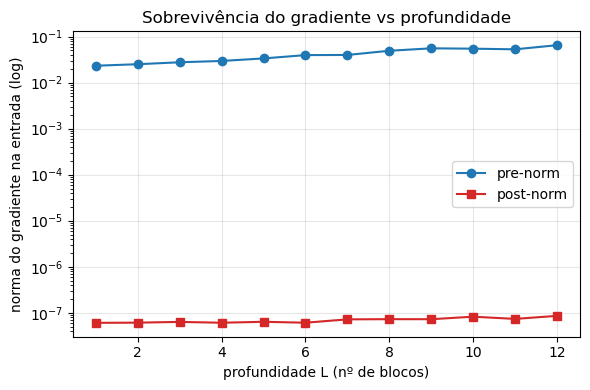

In [8]:
Ls = list(range(1, 13))
pre  = [grad_que_chega_na_entrada(prenorm=True,  L=L) for L in Ls]
post = [grad_que_chega_na_entrada(prenorm=False, L=L) for L in Ls]

fig, ax = plt.subplots()
ax.plot(Ls, pre,  "o-", color="C0", label="pre-norm")
ax.plot(Ls, post, "s-", color="C3", label="post-norm")
ax.set_yscale("log")
ax.set_xlabel("profundidade L (nº de blocos)")
ax.set_ylabel("norma do gradiente na entrada (log)")
ax.set_title("Sobrevivência do gradiente vs profundidade")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Inicialização: por que escalar as projeções residuais por $1/\sqrt{2L}$

O GPT-2 inicializa os pesos `Linear` com $\mathcal{N}(0, 0.02^2)$ e os *biases* em
zero. Há um detalhe sutil (nb 03): as **projeções residuais** — a `out_proj`
da atenção e a `proj` (down) da MLP, isto é, exatamente os pesos cujo resultado é
**somado** de volta na rodovia residual — recebem uma escala extra:

$$ W_{\text{out\_proj}},\, W_{\text{mlp\_down}} \sim \mathcal{N}\!\left(0, \left(\tfrac{0.02}{\sqrt{2L}}\right)^2\right) $$

**A razão é a soma na rodovia residual.** Cada bloco soma 2 ramos ($2L$ ramos no
total). Se cada ramo contribui com variância $\sigma^2$, a variância do fluxo
residual cresce **linearmente** com o número de ramos — a norma cresce $\sim\sqrt{2L}$.
Escalar cada projeção residual por $1/\sqrt{2L}$ cancela exatamente esse crescimento,
mantendo a norma $O(1)$ no início do treino. Vamos ver o efeito num experimento limpo.

In [9]:
# Simulação enxuta da rodovia residual: partimos de um fluxo de variância unitária
# e somamos 2L "ramos" (a saída de cada atenção/MLP). Comparamos SEM e COM a escala.
torch.manual_seed(0)
d_sim = 128
L = 12
n_branches = 2 * L                 # 2 ramos por bloco (atenção + MLP)
scale = 1.0 / math.sqrt(n_branches)

x_un = torch.randn(d_sim)          # fluxo inicial (embeddings)
x_sc = x_un.clone()
norms_un, norms_sc = [x_un.norm().item()], [x_sc.norm().item()]
for _ in range(n_branches):
    branch = torch.randn(d_sim)    # saída de um ramo, variância unitária
    x_un = x_un + branch           # SEM escala
    x_sc = x_sc + scale * branch   # COM escala 1/sqrt(2L)
    norms_un.append(x_un.norm().item())
    norms_sc.append(x_sc.norm().item())

print(f"norma inicial:                 {norms_un[0]:.2f}")
print(f"norma final SEM escala:        {norms_un[-1]:.2f}   (cresceu ~sqrt(2L) = {math.sqrt(1+n_branches):.2f}x)")
print(f"norma final COM escala 1/√2L:  {norms_sc[-1]:.2f}   (permaneceu O(1))")
assert norms_un[-1] > 3 * norms_sc[-1], "esperado: sem escala cresce muito mais"
print("OK: a escala 1/sqrt(2L) mantém a norma da rodovia residual controlada.")

norma inicial:                 11.77
norma final SEM escala:        59.12   (cresceu ~sqrt(2L) = 5.00x)
norma final COM escala 1/√2L:  16.68   (permaneceu O(1))
OK: a escala 1/sqrt(2L) mantém a norma da rodovia residual controlada.


A figura mostra a norma da rodovia residual crescendo a cada ramo somado. **Sem
escala** (vermelho) a norma sobe como $\sqrt{\text{nº de ramos}}$ (linha tracejada
= a previsão teórica $\sqrt{1+2L}$); **com a escala** $1/\sqrt{2L}$ (azul) ela fica
plana em $O(1)$. É exatamente esse crescimento que a inicialização do GPT-2 cancela
para manter o treino estável no início.

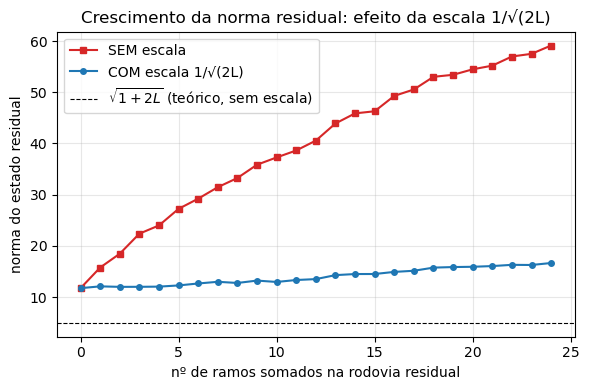

In [10]:
fig, ax = plt.subplots()
passos = range(len(norms_un))
ax.plot(passos, norms_un, "s-", color="C3", ms=4, label="SEM escala")
ax.plot(passos, norms_sc, "o-", color="C0", ms=4, label="COM escala 1/√(2L)")
ax.axhline(math.sqrt(1 + n_branches), color="k", ls="--", lw=0.8,
           label=r"$\sqrt{1+2L}$ (teórico, sem escala)")
ax.set_xlabel("nº de ramos somados na rodovia residual")
ax.set_ylabel("norma do estado residual")
ax.set_title("Crescimento da norma residual: efeito da escala 1/√(2L)")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Montando o modelo completo (com init e *weight tying*)

Agora juntamos tudo num `TucanoCE` de brinquedo. Dois pontos da montagem final:

- **Init em duas passadas:** primeiro `apply(_init_weights)` põe todo `Linear`/`Embedding`
  em $\mathcal{N}(0,0.02^2)$ e zera *biases*; depois **sobrescrevemos** as projeções
  residuais com a escala $1/\sqrt{2L}$.
- **Weight tying (nb 03):** a embedding de tokens $W_e$ e a projeção final para
  *logits* compartilham os mesmos pesos, $W_{\text{lm\_head}} = W_e^\top$. Em código,
  basta `lm_head.weight = tok_emb.weight`. Economiza $V\cdot d$ parâmetros e tende a
  melhorar a qualidade.

In [11]:
class TucanoCE(nn.Module):
    def __init__(self, vocab, d, L, n_heads, context_len):
        super().__init__()
        self.context_len = context_len
        self.tok_emb = nn.Embedding(vocab, d)
        self.pos_emb = nn.Embedding(context_len, d)
        self.blocks = nn.ModuleList([Block(d, n_heads, prenorm=True) for _ in range(L)])
        self.ln_f = nn.LayerNorm(d)
        self.lm_head = nn.Linear(d, vocab, bias=False)
        self.lm_head.weight = self.tok_emb.weight        # <-- weight tying

        # init em duas passadas
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            # projeções residuais = as que somam de volta na rodovia:
            # atenção.out_proj e mlp.proj (down). Ambas recebem a escala 1/sqrt(2L).
            if name.endswith("out_proj.weight") or name.endswith("mlp.proj.weight"):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * L))

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.context_len
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        return self.lm_head(x)                            # logits (B, T, vocab)

    def num_params(self):
        # parameters() já deduplica o peso compartilhado (tok_emb == lm_head)
        return sum(p.numel() for p in self.parameters())

model = TucanoCE(vocab=100, d=32, L=2, n_heads=4, context_len=16)
print(model)

TucanoCE(
  (tok_emb): Embedding(100, 32)
  (pos_emb): Embedding(16, 32)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=32, out_features=96, bias=True)
        (out_proj): Linear(in_features=32, out_features=32, bias=True)
      )
      (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): MLP(
        (fc): Linear(in_features=32, out_features=128, bias=True)
        (proj): Linear(in_features=128, out_features=32, bias=True)
      )
    )
  )
  (ln_f): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=32, out_features=100, bias=False)
)


### Conferindo o *forward*, o *weight tying* e o init

Três checagens deterministas:
1. o *forward* devolve *logits* de shape $(B, T, V)$;
2. `tok_emb.weight` e `lm_head.weight` são o **mesmo** tensor na memória (mesmo `data_ptr`);
3. as projeções residuais têm desvio-padrão $\approx 0.02/\sqrt{2L}$, menor que os
   demais `Linear` ($\approx 0.02$).

In [12]:
idx = torch.randint(0, 100, (2, 16))
logits = model(idx)
print("1) logits:", tuple(logits.shape), "= (B, T, vocab) ✓")

tied = model.tok_emb.weight.data_ptr() == model.lm_head.weight.data_ptr()
print("2) weight tying (mesmo storage)?", tied,
      "| is:", model.tok_emb.weight is model.lm_head.weight)

std_res = model.blocks[0].mlp.proj.weight.std().item()
std_lin = model.blocks[0].mlp.fc.weight.std().item()
esperado = 0.02 / math.sqrt(2 * 2)     # L=2
print(f"3) std projeção residual: {std_res:.4f} (esperado ~{esperado:.4f}) "
      f"| std Linear comum: {std_lin:.4f} (~0.02)")
assert tied and std_res < std_lin
print("\nTodas as checagens passaram.")

1) logits: (2, 16, 100) = (B, T, vocab) ✓
2) weight tying (mesmo storage)? True | is: True
3) std projeção residual: 0.0101 (esperado ~0.0100) | std Linear comum: 0.0197 (~0.02)

Todas as checagens passaram.


In [13]:
# Economia do weight tying: V*d parâmetros que NÃO são duplicados.
V_full, d_full = 8192, 512          # preset 'medium' do projeto
economia = V_full * d_full
total_medium = 43_000_000
print(f"weight tying economiza V*d = {economia:,} params (~{economia/1e6:.1f}M)")
print(f"no 'medium' (~43M), isso é ~{100*economia/total_medium:.0f}% do modelo")
print(f"\nmodelo de brinquedo deste notebook: {model.num_params():,} parâmetros")

weight tying economiza V*d = 4,194,304 params (~4.2M)
no 'medium' (~43M), isso é ~10% do modelo

modelo de brinquedo deste notebook: 29,184 parâmetros


Onde moram os parâmetros? A figura agrupa os pesos do modelo brinquedo por
componente. Mesmo aqui a **MLP** já domina o orçamento dos blocos — no GPT-2/GPT-3
real ela concentra ~2/3 do total. É contraintuitivo: a "atenção" dá nome à
arquitetura, mas a maior parte da capacidade está nas MLPs (nb 01).

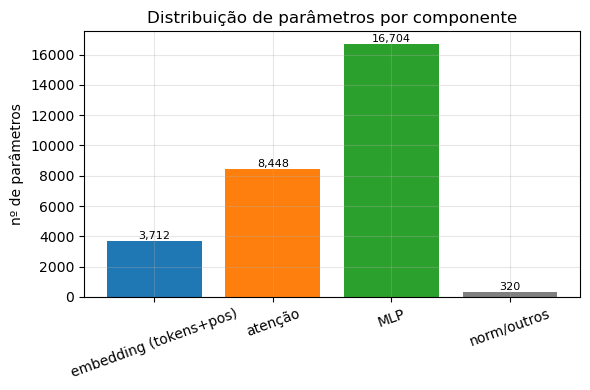

In [14]:
# Agrupa os parâmetros por componente a partir do nome (parameters() já deduplica
# o weight tying, então a embedding aparece uma vez só).
grupos = {"embedding (tokens+pos)": 0, "atenção": 0, "MLP": 0, "norm/outros": 0}
for name, p in model.named_parameters():
    n = p.numel()
    if "emb" in name:                         grupos["embedding (tokens+pos)"] += n
    elif "attn" in name:                      grupos["atenção"] += n
    elif "mlp" in name:                       grupos["MLP"] += n
    else:                                     grupos["norm/outros"] += n

labels, vals = list(grupos.keys()), list(grupos.values())
fig, ax = plt.subplots()
bars = ax.bar(labels, vals, color=["C0", "C1", "C2", "C7"])
ax.set_ylabel("nº de parâmetros"); ax.set_title("Distribuição de parâmetros por componente")
ax.tick_params(axis="x", rotation=20)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

### Sanity-check do init: a loss inicial deveria ser $\approx \log V$

Antes de treinar, o modelo é ignorante: com pesos pequenos e simétricos, os
*logits* saem quase uniformes, então a distribuição prevista é ~uniforme sobre os
$V$ tokens. A cross-entropy de uma uniforme é exatamente $\log V$ — o **piso
trivial** "sem modelo" (voltamos a ele no nb 07, ao interpretar bits-per-token e
Chinchilla). Se a loss no passo 0 estiver longe de $\log V$, o init está errado
(ex.: pesos grandes demais saturando os *logits*). É a primeira coisa que se
confere ao subir um treino.

In [15]:
# Loss no init contra o piso trivial log(V).
idx = torch.randint(0, 100, (4, 16))
targets = torch.randint(0, 100, (4, 16))           # alvos aleatórios
logits = model(idx)
loss = F.cross_entropy(logits.reshape(-1, 100), targets.reshape(-1))

import math as _m
print(f"loss no init      : {loss.item():.3f} nats")
print(f"piso trivial log V: {_m.log(100):.3f} nats  (V=100)")
print(f"razão             : {loss.item()/_m.log(100):.2f}  (~1.0 => init saudável)")
assert abs(loss.item() - _m.log(100)) < 0.5, "init suspeito: loss longe de log(V)"
print("\nOK: no passo 0 o modelo está no piso trivial, como esperado.")

loss no init      : 4.606 nats
piso trivial log V: 4.605 nats  (V=100)
razão             : 1.00  (~1.0 => init saudável)

OK: no passo 0 o modelo está no piso trivial, como esperado.


## Resumo (o que carregar para o notebook 04)

| Peça (base GPT-2) | Como ficou aqui | O que o nb 04 troca |
|---|---|---|
| Normalização | `nn.LayerNorm`, *pre-norm* | → **RMSNorm** |
| Posição | embedding posicional aprendida | → **RoPE** (rotação em Q,K) |
| MLP | GELU com expansão 4d | → **SwiGLU** |
| Atenção | `scaled_dot_product_attention`, causal | + **KV-cache** na inferência |
| Init | $\mathcal{N}(0,0.02^2)$; residual $\times 1/\sqrt{2L}$ | (mantém) |
| Saída | *weight tying* $W_{lm}=W_e^\top$ | (mantém) |

**O que fica gravado:** o *forward* de um decoder-only é `Embed → L blocos pre-norm
→ Norm → logits`, com uma rodovia residual limpa cuja norma é mantida $O(1)$ pela
escala $1/\sqrt{2L}$. Isso alimenta diretamente `src/tucanoce/model/block.py` e
`src/tucanoce/model/transformer.py` — que já vêm com os *slots* de RMSNorm/SwiGLU/RoPE
esperando o notebook 04.

Próximo: **`04_modernizacao_llama.ipynb`** — RMSNorm, SwiGLU, RoPE e KV-cache.